# Example: Sex Ratios (Pandas Version)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = 'http://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2010-2019/nc-est2019-agesex-res.csv'
full_df = pd.read_csv(data)
full_df.head()

,SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
1,0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
2,0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
3,0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
4,0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323


## The Code Used in the `SEX` Column

The contents of the `AGE`, `2014`, and `2019` columns are straightforward to understand. The `AGE` column contains ages in completed years. The special value `999` represents the entire population regardless of age, and `100` represents "100 or more". The `2014` and `2019` columns contain estimates of the US population in each of the two years.

The SEX column, however, is more difficult to interpret. 
 
The Census form asks respondents to provide the sex of each household member by checking one of two boxes labeled Male and Female. The `SEX` column contains numeric codes: `1` for male, `2` for female, and `0` for the total.

This question has been asked in essentially the same way since 1790. But since then there has been considerable [research](https://pubmed.ncbi.nlm.nih.gov/11534012/) on whether the sex of human beings lends itself to simple binary categorization. For example, nonbinary people do not identify exclusively as male or female. A [study](https://williamsinstitute.law.ucla.edu/publications/nonbinary-lgbtq-adults-us/) by the Williams Institute at the UCLA School of Law in 2021 estimated that at least 1.2 million individuals in the United States identify as nonbinary. 

By continuing to use the historical form of the question, the Census fails to reflect the complexity of sex classification. The [explanation](https://www2.census.gov/programs-surveys/decennial/2020/partners/outreach-materials/handouts/why-we-ask-the-sex-question.pdf) provided in the 2020 Census and reproduced in the quotation below does not include instructions for those who do not identify as one of Male or Female.

> **Responding to the sex question is easy.**
>
>A question on sex has been included since the first census in 1790. All 2020 Census questions that involve personal characteristics are based on self-identification. When you complete your census, select the box for the biological sex you identify with.
>

Regardless of the opinion expressed above, responding to this question isn’t easy for everyone. Difficulties with answering the question can lead to non-response or inaccurate responses. This can reduce the accuracy of Census data for informing policy decisions and allocating resources.

Before the 2020 Census, the Census Bureau considered revising this question or including broader questions about sexual orientation and gender identity. In the end the Bureau decided [not to change](https://www.census.gov/newsroom/blogs/director/2017/03/planned_subjects_2020.html) the planned Census. 

However, Census Director John Thompson wrote, “The Census Bureau remains committed to reflecting the information needs of our changing society.” Census forms do change. For example, [new questions on race and ethnicity](https://www.census.gov/library/stories/2021/08/improved-race-ethnicity-measures-reveal-united-states-population-much-more-multiracial.html) in the 2020 Census have led to a more accurate understanding of US demographics. We can hope that the 2030 Census will be more inclusive and accurate in all respects. 

In what follows, we will use the data provided by the Census keeping in mind the issues described above. We will use the term "male" to mean an individual for whom "Male" (`SEX` code 1) was selected on the Census form. We will use "female" to mean an individual for whom "Female" (`SEX`code 2) was selected. 

In [3]:
partial_df = full_df[['SEX','AGE','POPESTIMATE2014','POPESTIMATE2019']]
us_pop = partial_df.rename(columns={'POPESTIMATE2014':'2014','POPESTIMATE2019':'2019'})
us_pop.head()

,SEX,AGE,2014,2019
0,0,0,3954787,3783052
1,0,1,3948891,3829599
2,0,2,3958711,3922044
3,0,3,4005928,3998665
4,0,4,4004032,4043323


In [4]:
# 2019 only
us_pop_2019 = us_pop.drop(columns=['2014'])
all_ages = us_pop_2019[us_pop_2019['AGE'] == 999]
all_ages

,SEX,AGE,2019
101,0,999,328239523
203,1,999,161657324
305,2,999,166582199


## Overall Proportions
We will now begin looking at sex ratios in 2019. First, let's look at all the age groups together. Remember that this means looking at the rows where the "age" is coded 999. The table `all_ages` contains this information. There are three rows: one for the total population, one for males, and one for females.

Row 0 of `all_ages` contains the total U.S. population in each of the two years. The United States had about 330 million people in 2019.

Row 1 contains the counts for males and Row 2 for females. Compare these two rows to see that in 2019, there were more females than males in the United States. 

The population counts in Row 1 and Row 2 add up to the total population in Row 0. 

For comparability with other quantities, we will need to convert these counts to percents out of the total population. Let's access the total for 2019 and name it. Then, we'll show a population table with a proportion column. Consistent with our earlier observation that there were more females than males, 50.75% of the population in 2019 was female and about 49.25% was male. 

In [5]:
# Proportions
pop_2019 = all_ages['2019'].iloc[0]
all_ages.assign(Proportion=all_ages['2019']/pop_2019)

,SEX,AGE,2019,Proportion
101,0,999,328239523,1.000000
203,1,999,161657324,0.492498
305,2,999,166582199,0.507502


## Proportions Among Infants

When we look at infants, however, the opposite is true. Let's define infants to be babies who have not yet completed one year, represented in the rows corresponding to `AGE` 0. Here are their numbers in the population. You can see that male infants outnumbered female infants.

As before, we can convert these counts to percents out of the total numbers of infants. The resulting table shows that in 2019, just over 51% of infants in the U.S. were male. 

In [6]:
# Infants
infants = us_pop_2019[us_pop_2019['AGE'] == 0]
inf_total = infants['2019'].iloc[0]
infants.assign(Proportion=infants['2019']/inf_total)

,SEX,AGE,2019,Proportion
0,0,0,3783052,1.000000
102,1,0,1935117,0.511523
204,2,0,1847935,0.488477


In fact, it has long been observed that the proportion of males among newborns is slightly more than 1/2. The reason for this is not thoroughly understood, and [scientists are still working on it](http://www.npr.org/sections/health-shots/2015/03/30/396384911/why-are-more-baby-boys-born-than-girls).

## Sex Ratio at Each Age 
We have seen that while there are more male infants than female, there are more females than males in the population overall. That means the split between sexes must vary across age groups.

To study this variation, we will separate out the data for the females and the males, and eliminate the row where all the ages are aggregated and `AGE` is coded as 999.

The tables `females` and `males` contain the data for each the two sex codes.

### Another wrinkle
You may want to get just the values out of a DataFrame Column. You will see that this gives us an array that can be used as the value in a dictionary when defining a new DataFrame. we use the `.values` attribute applied to specific column. The arrays that come out are numpy arrays. That means we can do entry-wise arithmetic on them as we have before.

In [18]:
type(females['AGE'].values)

numpy.ndarray

In [19]:
# Compute ratios
ratios = pd.DataFrame({
    'AGE': females['AGE'].values, # here we're using .values to get an array
    '2019 F:M RATIO': females['2019'].values / males['2019'].values # element wise division gives us the ratio for each age.
})
ratios.head(10)

,AGE,2019 F:M RATIO
0,0,0.954947
1,1,0.955289
2,2,0.955601
3,3,0.957242
4,4,0.956177
5,5,0.954338
6,6,0.956801
7,7,0.956633
8,8,0.955161
9,9,0.959278


You can see from the display that the ratios are all around 0.96 for children aged nine or younger. When the Female:Male ratio is less than 1, there are fewer females than males. Thus we are seeing that there were fewer girls than boys in each of the age groups 0, 1, 2, and so on through 9. More precisely, in each of these age groups there were about 96 girls for every 100 boys.

Then how can the overall proportion of females in the population be higher than the males? 

Something quite different happens when we examine the other end of the age range. Here are the Female:Male ratios for people aged more than 75.

In [ ]:
# Ages above 75
ratios[ratios['AGE'] > 75].head(-10) # here's a neat trick to look at the eand of a DataFrame: negative value in .head()!

,AGE,2019 F:M RATIO
76,76,1.214222
77,77,1.235576
78,78,1.263727
79,79,1.281286
80,80,1.292093
81,81,1.327453
82,82,1.361014
83,83,1.397488
84,84,1.446027
85,85,1.485885


Not only are all of these ratios greater than 1, signifying more women than men in all of these age groups, many of them are considerably greater than 1. 

- At ages 92 and 93 the ratios are close to 2, meaning that there were about twice as many women as men at those ages in 2019.
- At ages 99 there were about 3 times as many women as men. 

If you are wondering how many people there were at these advanced ages, you can use Python to find out:

The graph below shows sex ratios plotted against age. The blue curve shows the 2019 ratios by age.

The ratios are almost 1 (signifying close to equal numbers of males and females) for ages 0 through 60. But they start shooting up dramatically (more females than males) starting in the 65 to 70 range.

That females outnumber males in the U.S. is partly due to the marked imbalance in favor of women among senior citizens.

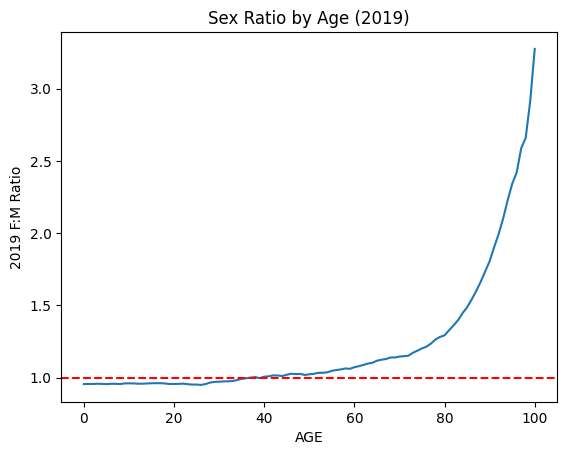

In [12]:
# Plot
plt.figure()
plt.plot(ratios['AGE'], ratios['2019 F:M RATIO'])
plt.axhline(y=1, color='red', linestyle='--')
plt.xlabel('AGE')
plt.ylabel('2019 F:M Ratio')
plt.title('Sex Ratio by Age (2019)')
plt.show()